In [4]:
import pandas as pd
from plotnine import *

In [16]:
df = pd.read_csv('DATA/OUTPUT/MHW_summary_table_wide_oisst.19812025.Portugal_200m_bathymetry.csv')
df.fillna(0.0, inplace=True)
df.head()

,Year,Month,Zone,activity_degC_days_m2,mean_area_km2,mean_duration_days,mean_intensity_degC,number_of_events,sum_area_km2
0,1981,9,NW,0.0,0.0,0.0,0.0,0.0,0.0
1,1981,9,S,0.0,0.0,0.0,0.0,0.0,0.0
2,1981,9,SW,0.0,0.0,0.0,0.0,0.0,0.0
3,1981,10,NW,0.0,0.0,0.0,0.0,0.0,0.0
4,1981,10,S,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
df['Datetime']= pd.to_datetime(dict(year= df['Year'], month= df['Month'], day=1))

In [26]:
df['Year'] = df['Year'].astype('float')

In [44]:
ag = pd.DataFrame(df.groupby(['Year', 'Zone'])['mean_duration_days'].mean()).reset_index()

ag

,Year,Zone,mean_duration_days
0,1981.0,NW,0.000000
1,1981.0,S,1.250000
2,1981.0,SW,1.343750
3,1982.0,NW,0.916667
4,1982.0,S,1.050000
...,...,...,...
130,2024.0,S,11.561111
131,2024.0,SW,9.156177
132,2025.0,NW,3.378162
133,2025.0,S,7.118056


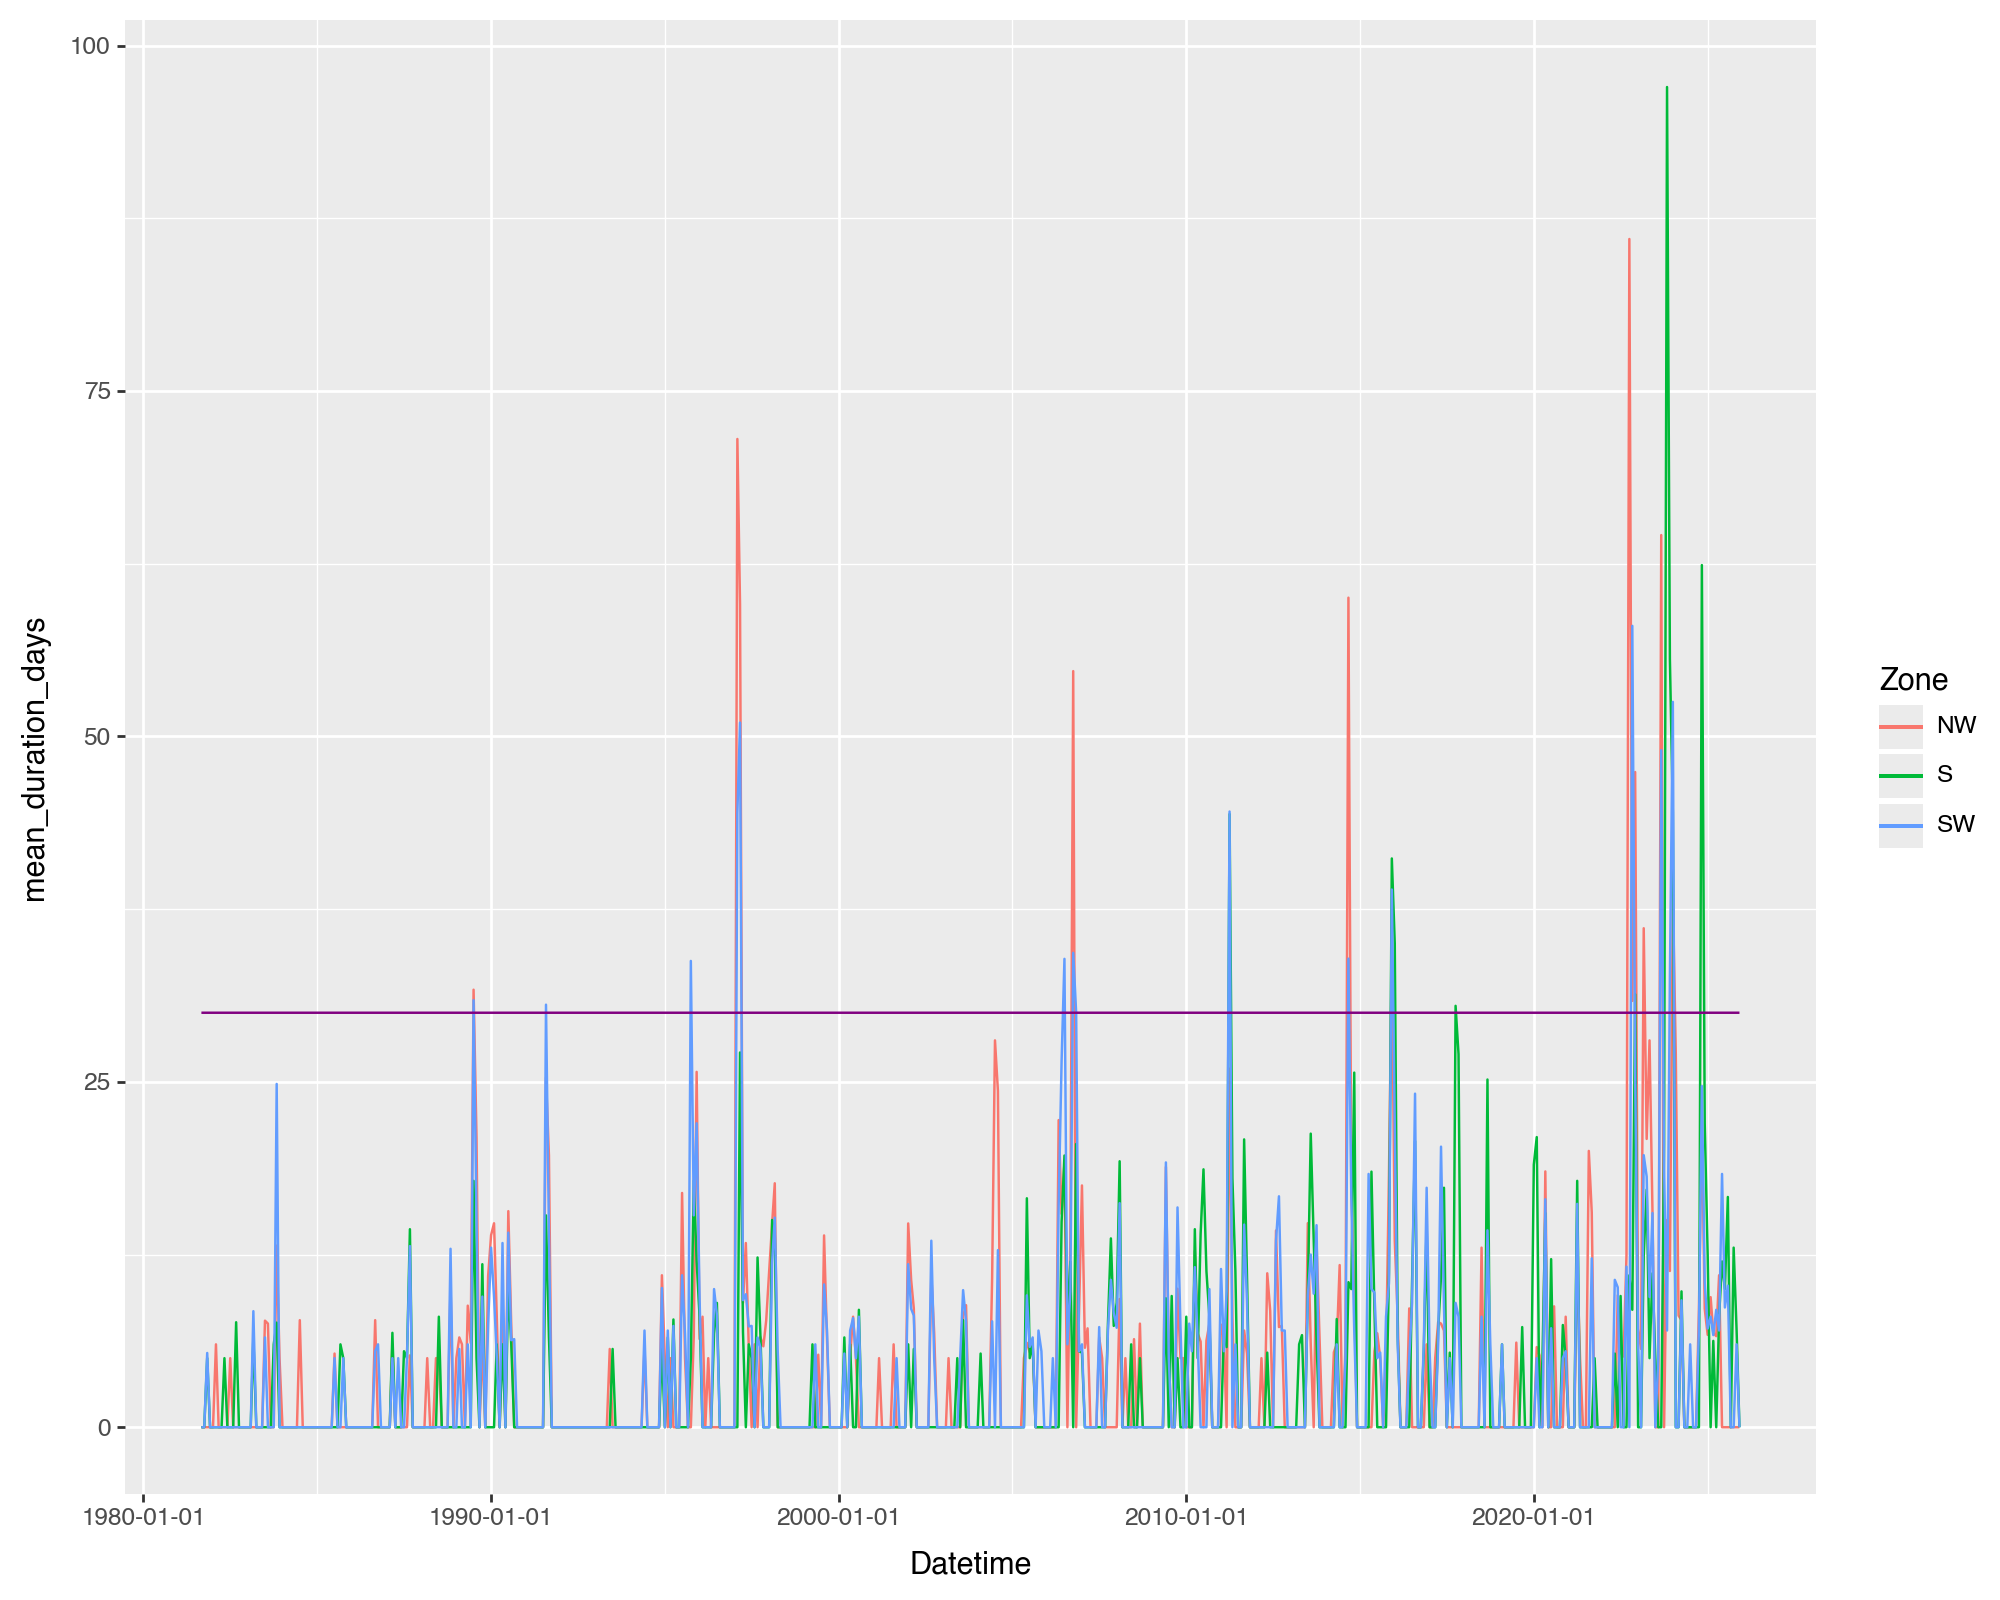

In [ ]:
(
    ggplot(df, aes('Datetime', 'mean_duration_days', color= 'Zone'))
    + geom_line()
    + geom_line(aes('Datetime', 30), color= 'purple')
    + theme(figure_size=(10, 8))
)

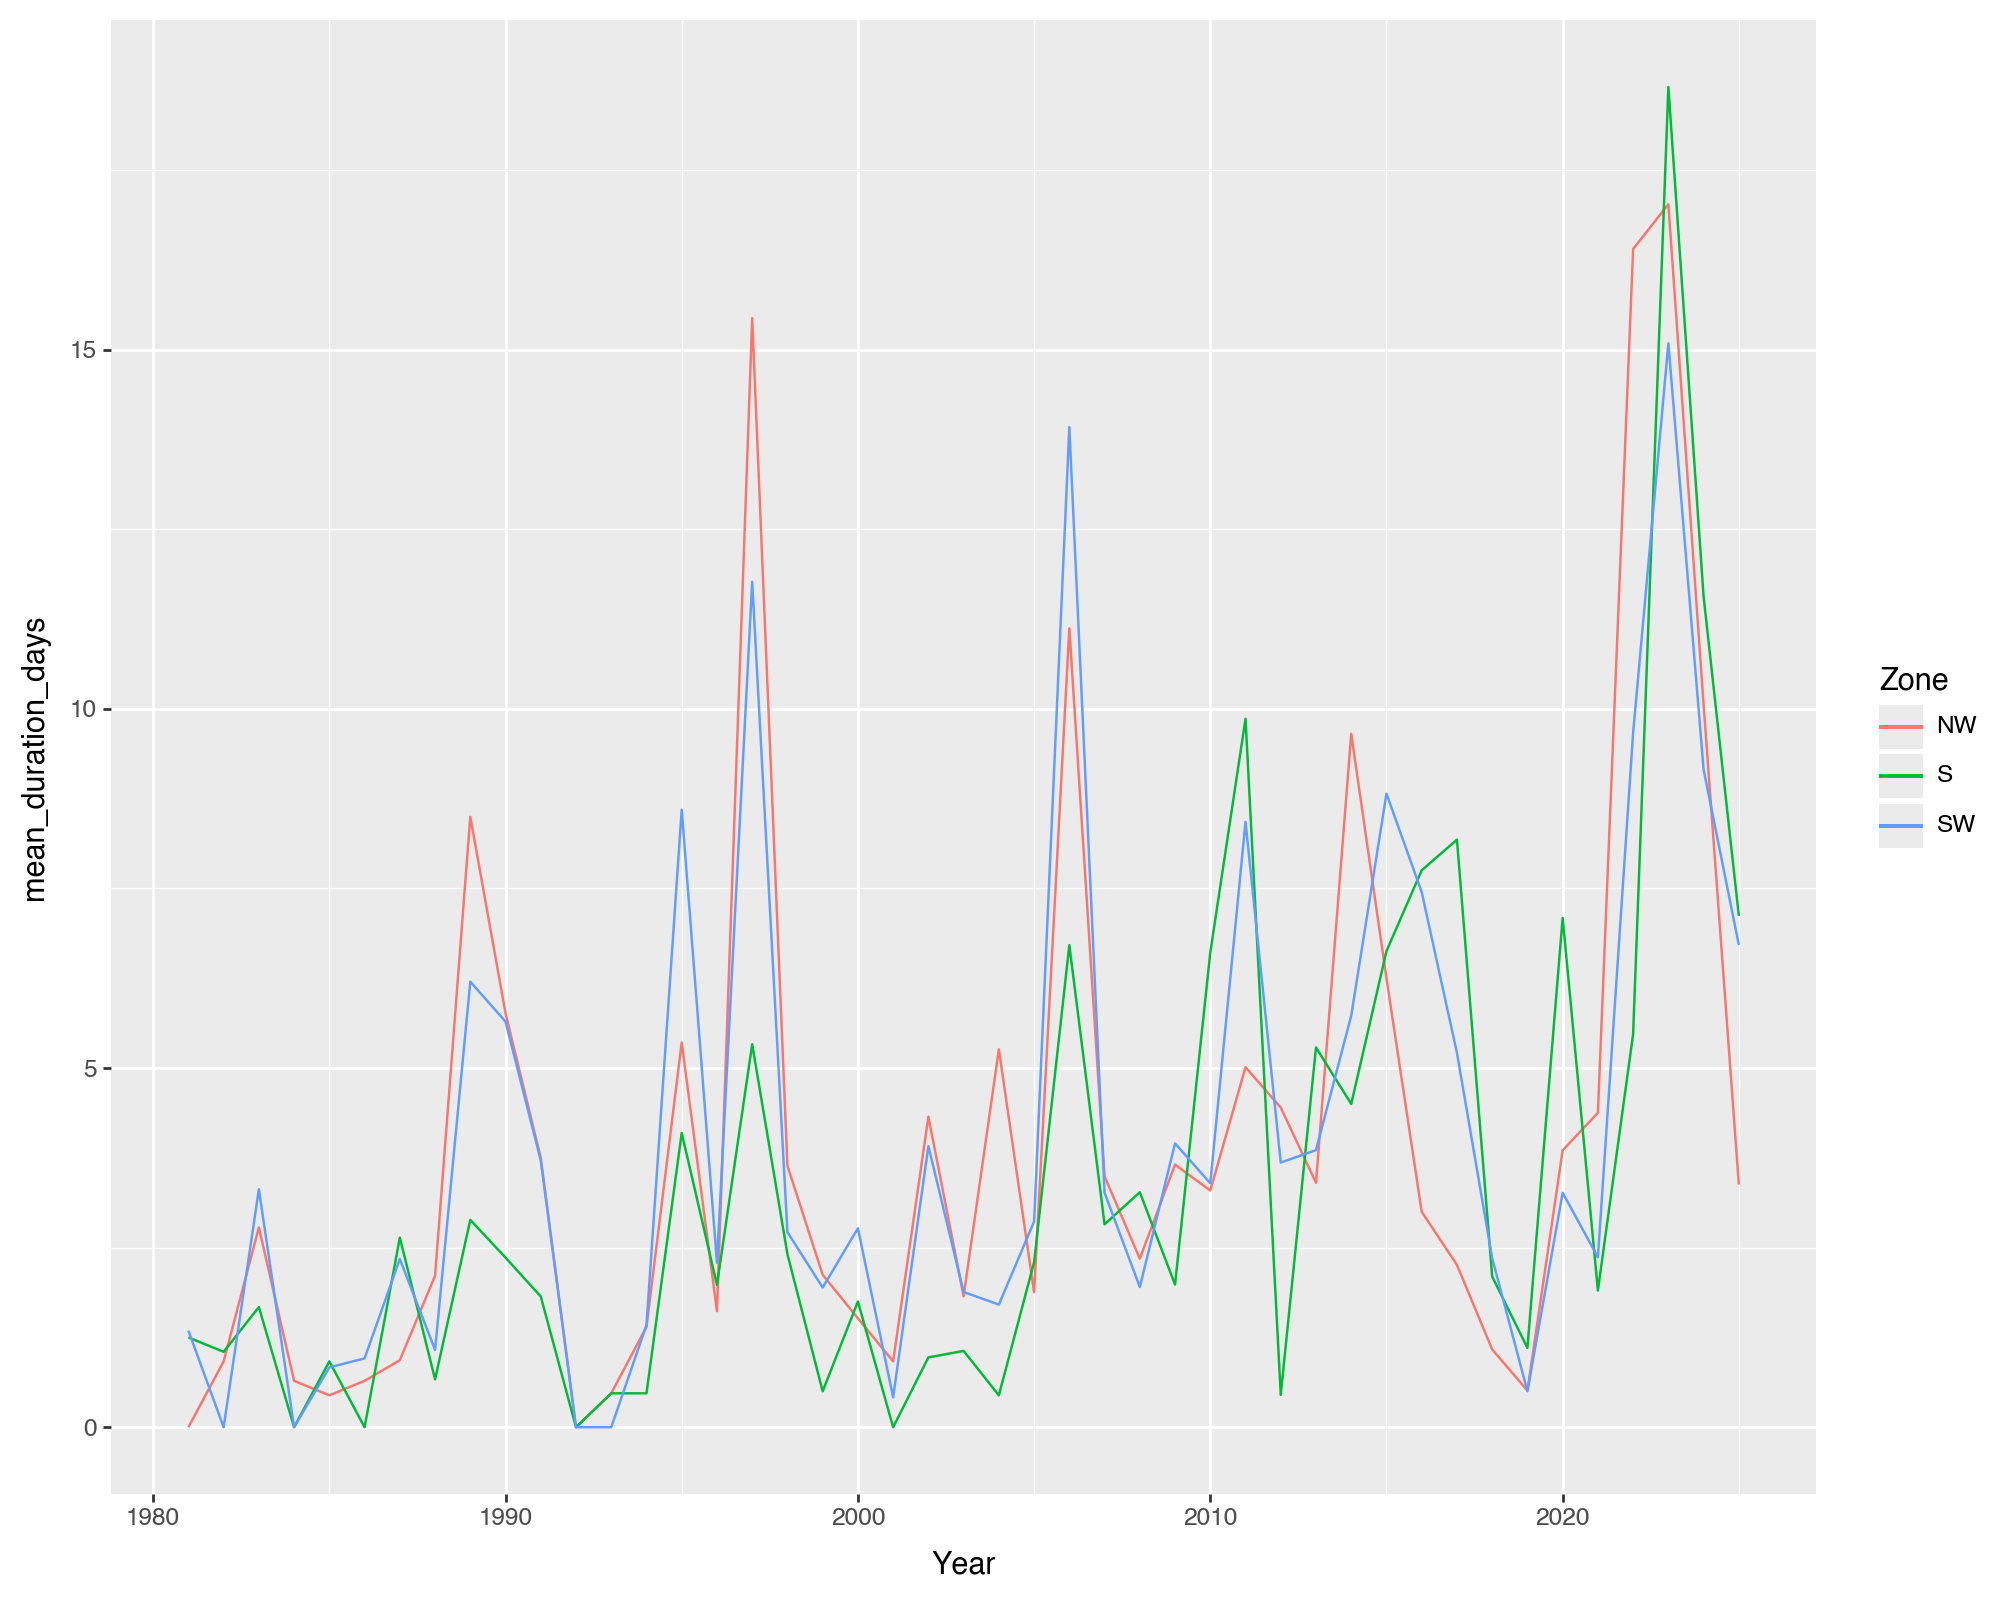

In [47]:
(
    ggplot(ag, aes('Year', 'mean_duration_days', color= 'Zone'))
    + geom_line()
    + theme(figure_size=(10, 8))
)